In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg as la
from matplotlib.collections import LineCollection

from tqdm import tqdm

from koala.pointsets import uniform
from koala.voronization import generate_lattice
from koala.lattice import cut_boundaries
from koala.graph_utils import make_dual, lloyd_relaxation, remove_trailing_edges
from koala import plotting as kplt
import matplotlib
from matplotlib.colors import TwoSlopeNorm

matplotlib.rcParams.update({'font.size': 11, 'text.usetex': True, 'font.family': 'serif', 'font.serif': ['Computer Modern']})

In [18]:
def qwz_hamiltonian(lattice, u_vals, h_field = 0):
    if isinstance(u_vals, (int, float, complex)):
        u_vals = np.array([u_vals] * lattice.n_vertices)

    a_site_part = np.diag(u_vals+0j)
    b_site_part = -np.diag(u_vals+0j)

    ab_link_part = np.zeros((lattice.n_vertices, lattice.n_vertices), dtype = complex)
    ba_link_part = np.zeros((lattice.n_vertices, lattice.n_vertices), dtype = complex)

    p1 = lattice.vertices.positions[lattice.edges.indices[:, 0]]
    p2 = lattice.vertices.positions[lattice.edges.indices[:, 1]]   
    average_y = 0.5*(p1[:,1] + p2[:,1])
    change_x = p2[:,0] - p1[:,0]
    phases = -h_field * average_y * change_x * lattice.n_plaquettes

    for edge_index in range(lattice.n_edges):

        field_phase = 1j*phases[edge_index]*2*np.pi
        
        edge = lattice.edges.indices[edge_index]

        vec = lattice.edges.vectors[edge_index]
        angle = np.angle(vec[0] + 1j * vec[1])

        ab_link_part[edge[0], edge[1]] = 0.5j*np.exp(-1j*angle + field_phase)
        ba_link_part[edge[0], edge[1]] = 0.5j*np.exp(1j*angle + field_phase)
        a_site_part[edge[0], edge[1]] = 0.5*np.exp(field_phase)
        b_site_part[edge[0], edge[1]] = -0.5*np.exp(field_phase)

        # add conjugates
        ba_link_part[edge[1], edge[0]] = -0.5j*np.exp(1j*angle - field_phase)
        ab_link_part[edge[1], edge[0]] = -0.5j*np.exp(-1j*angle - field_phase)
        a_site_part[edge[1], edge[0]] = 0.5*np.exp(-field_phase)
        b_site_part[edge[1], edge[0]] = -0.5*np.exp(-field_phase)

    return np.block([
        [a_site_part, ab_link_part],
        [ba_link_part, b_site_part]
    ])

def step_marker(l, P):
    positions = l.vertices.positions 
    step_x = (positions[:,0]-0.5) > 0
    step_y = (positions[:,1]-0.5) > 0
    step_x = np.kron(np.ones(2), step_x)
    step_y = np.kron(np.ones(2), step_y)
    step_marker = (((P*step_x) @ (P*step_y) - (P*step_y) @ (P*step_y))@ P).diagonal().imag
    return step_marker[:l.n_vertices] + step_marker[l.n_vertices:]


In [19]:
points = uniform(1000)
lattice = lloyd_relaxation(generate_lattice(points))
lattice_strip = remove_trailing_edges(cut_boundaries(lattice, [True, True]))


In [20]:
n_values = 6

chaos_values = np.linspace(0, 2.1, 6, endpoint = False)

results = []

for c in tqdm(chaos_values):
    u_chaos = np.random.normal(0, c, lattice_strip.n_vertices)
    h = qwz_hamiltonian(lattice_strip, -0.5 + u_chaos)
    e, v = la.eigh(h)
    results.append((h,e,v))


100%|██████████| 6/6 [01:43<00:00, 17.27s/it]


In [21]:
markers = []
for n in tqdm(range(len(chaos_values))):
    h, e, v = results[n]
    proj = v * (e<0) @ v.T.conj()
    marker = step_marker(lattice_strip, proj)
    markers.append(marker)

100%|██████████| 6/6 [00:56<00:00,  9.49s/it]


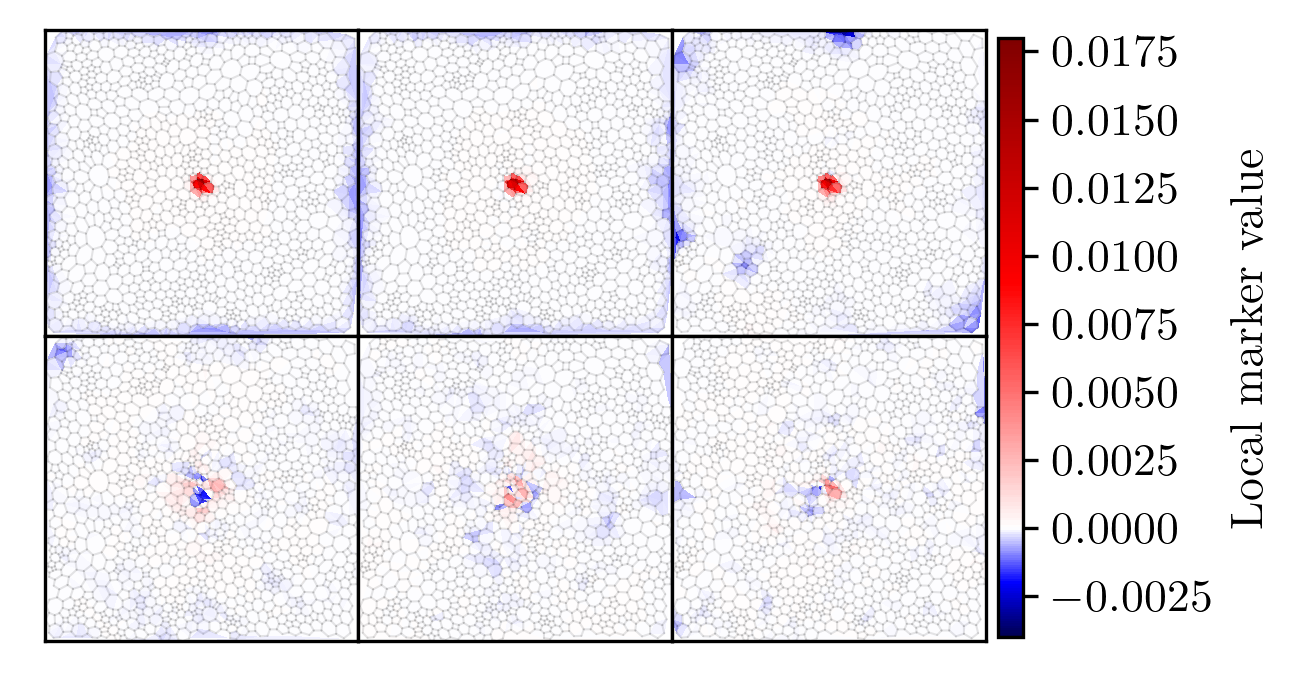

In [22]:
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable


height = 2.7
width = n_values*height/4

fig, axes = plt.subplots(2,n_values//2, figsize = (width,height), sharex = True, sharey = True, dpi = 300)
fig.subplots_adjust(hspace=0)
fig.subplots_adjust(wspace=0)
x_vals = lattice_strip.vertices.positions[:,0]
y_vals = lattice_strip.vertices.positions[:,1]

lower,upper = 0,0
for marker in markers:
    upper= max(upper, np.max(marker))
    lower = min(lower, np.min(marker))

# divnorm = colors.TwoSlopeNorm(vmin=lower, vcenter=0, vmax=upper)
divnorm = colors.TwoSlopeNorm(vmin=-0.004, vcenter=0, vmax=upper)

for n in range(len(chaos_values)):
    ax = axes.flatten()[n]
    z_vals = markers[n]
    ax.set_xticks([])
    ax.set_yticks([])
    kplt.plot_edges(lattice_strip, ax = ax, linewidth = 0.5, color = 'k', alpha = 0.1)
    # divnorm = colors.TwoSlopeNorm(vmin=z_vals.min(), vcenter=0, vmax=z_vals.max())
    pcm = ax.tripcolor(x_vals, y_vals, z_vals, norm= divnorm, cmap= 'seismic', rasterized=True)

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.91, 0.13, 0.02, 0.74 ])
fig.colorbar(pcm, cax=cbar_ax,label = 'Local marker value')

plt.savefig('kitaev_marker_increasing_disorder.pdf', bbox_inches='tight')


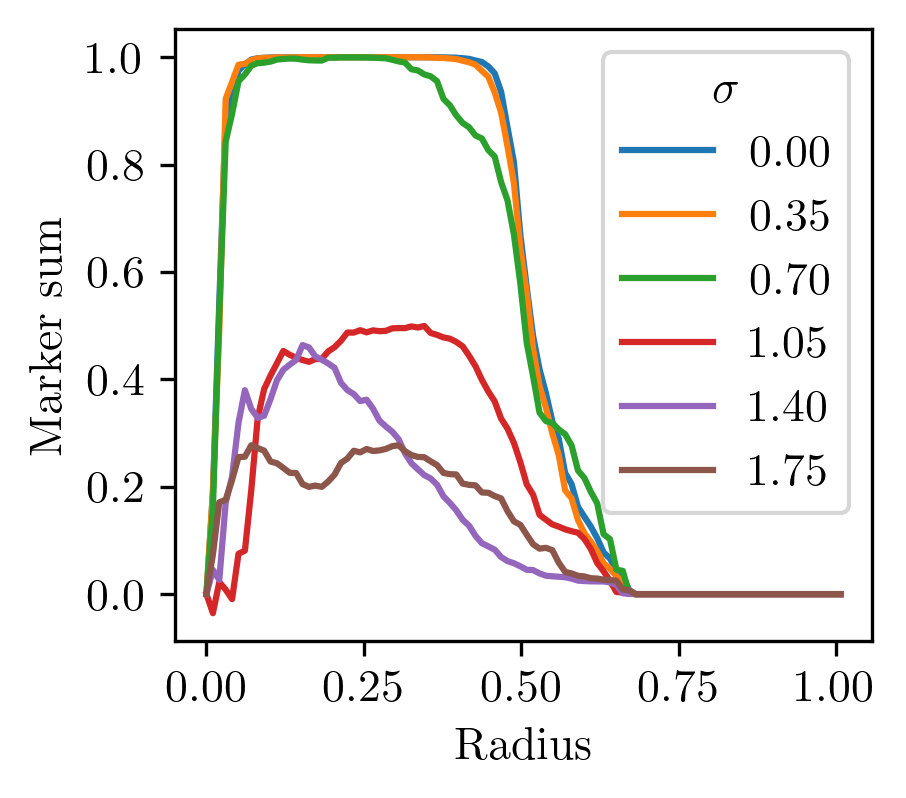

In [23]:
fig, ax = plt.subplots( figsize = (3,height), dpi = 300)

labels = [f'{c:.2f}' for c in chaos_values]


positions = lattice_strip.vertices.positions
distance_from_center = np.sqrt((positions[:,0]-0.5)**2 + (positions[:,1]-0.5)**2)

circle_sizes = np.linspace(0, np.sqrt(1/2)+0.3, 100)
indices_in_circle = [ np.argwhere(distance_from_center < r) for r in circle_sizes]

for n in range(len(chaos_values)):
    indices = indices_in_circle[n]
    values = [4*np.pi*np.sum(markers[n][indices]) for indices in indices_in_circle]

    plt.plot(circle_sizes, values, label = labels[n])

plt.legend(title = '$\sigma$', loc = 'upper right')
plt.xlabel('Radius')
plt.ylabel('Marker sum')

plt.savefig('kitaev_marker_increasing_disorder_sum.pdf', bbox_inches='tight')

In [24]:
for n in range(len(chaos_values)):
    indices = indices_in_circle[n]
    values = np.array([4*np.pi*np.sum(markers[n][indices]) for indices in indices_in_circle])
    print(values.max())

0.9999999265831865
0.9999990125074543
0.9998246526182338
0.4994898667186952
0.46383404065991496
0.2772679389009701
